In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense

In [2]:
# Contoh dataset dengan kolom: ['temperature', 'humidity', 'pressure', 'PM2.5', 'PM10']
#df = pd.read_csv('DataPengukuranSensor.csv')
df = pd.read_csv('data_sensor_gabungan_final.csv', header =0)

# Menampilkan 5 data teratas
print(df.head())
df.shape

  Tanggal Jam Curah Hujan    MQ-7 MQ-135 PM-2.5 PM-10 Arah Angin  \
0   00:01   0        7.89  199.00     24     24    23       5.18   
1   00:06   0        7.61  198.00     24     24    16       5.70   
2   00:11   0        7.28  195.00     24     24    16       5.30   
3   00:16   0        7.56  198.00     24     24    16       5.48   
4   00:21   0        9.69  243.00     24     24   106       4.68   

  Kecepatan Angin Kelembaban   Suhu    SO2    O3 O3_2;  
0           88.00      21.00  49.00  21.00  21.0     ;  
1           88.00      21.00  48.00  21.00  21.0     ;  
2           89.00      21.00  47.00  20.00  20.0     ;  
3           89.00      21.00  47.00  20.00  20.0     ;  
4           89.00      21.00  60.00  23.00  23.0     ;  


(53822, 14)

In [3]:
# Baca file: gunakan baris pertama sebagai header
#df = pd.read_csv('data_sensor_gabungan_final.csv', header=0)

# Perbaiki kolom yang mungkin bermasalah (misalnya ada titik koma di akhir)
# Bersihkan nama kolom dari spasi atau karakter aneh
df.columns = df.columns.str.strip().str.replace(';', '', regex=False)

# Konversi kolom numerik — pastikan semua data numerik, bukan string
numeric_cols = ['Arah Angin', 'Kecepatan Angin', 'Kelembaban', 'Suhu']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Hapus baris yang rusak (jika ada)
df.dropna(subset=numeric_cols, inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53189 entries, 0 to 53821
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tanggal          53189 non-null  object 
 1   Jam              53189 non-null  object 
 2   Curah Hujan      53189 non-null  object 
 3   MQ-7             53189 non-null  object 
 4   MQ-135           53189 non-null  object 
 5   PM-2.5           53189 non-null  object 
 6   PM-10            53189 non-null  object 
 7   Arah Angin       53189 non-null  float64
 8   Kecepatan Angin  53189 non-null  float64
 9   Kelembaban       53189 non-null  float64
 10  Suhu             53189 non-null  float64
 11  SO2              53189 non-null  object 
 12  O3               44403 non-null  float64
 13  O3_2             53189 non-null  object 
dtypes: float64(5), object(9)
memory usage: 6.1+ MB


In [5]:
# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 4. Konversi kolom numerik ke float, jika masih string
numeric_columns = ['Arah Angin', 'Kecepatan Angin', 'Kelembaban', 'Suhu']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Hapus baris yang memiliki nilai NaN setelah konversi
df.dropna(subset=numeric_columns, inplace=True)

# 6. Pisahkan fitur (X) dan target (y)
X = df[['Arah Angin', 'Kecepatan Angin', 'Kelembaban']]
y = df['Suhu']

# 7. Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Normalisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Cetak ukuran data untuk pengecekan
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("Persiapan data selesai! ✅")

X_train_scaled shape: (42551, 3)
X_test_scaled shape: (10638, 3)
Persiapan data selesai! ✅


In [6]:
# Membuat model regresi linier
lin_reg = LinearRegression()

# Melatih model regresi linier
lin_reg.fit(X_train_scaled, y_train)

# Prediksi suhu pada data test
y_pred_lin_reg = lin_reg.predict(X_test_scaled)

# Evaluasi model regresi linier
rmse_lin_reg = np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)

print(f'Regresi Linier - RMSE: {rmse_lin_reg}, MAE: {mae_lin_reg}')

Regresi Linier - RMSE: 6.750944789296176, MAE: 5.559267858368235


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Membuat model Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Melatih model Random Forest
rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)

# Evaluasi
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'Random Forest - RMSE: {rmse_rf}, MAE: {mae_rf}')


Random Forest - RMSE: 6.466863637793128, MAE: 4.812183402785417


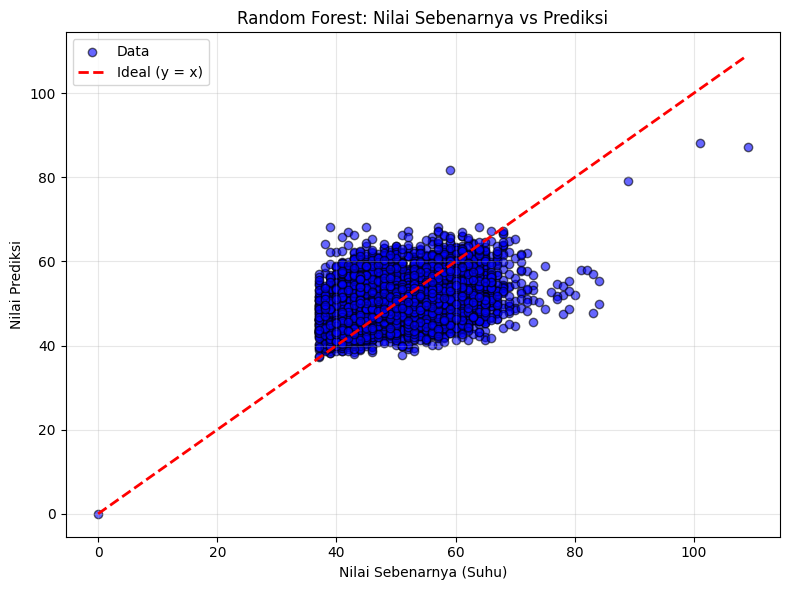

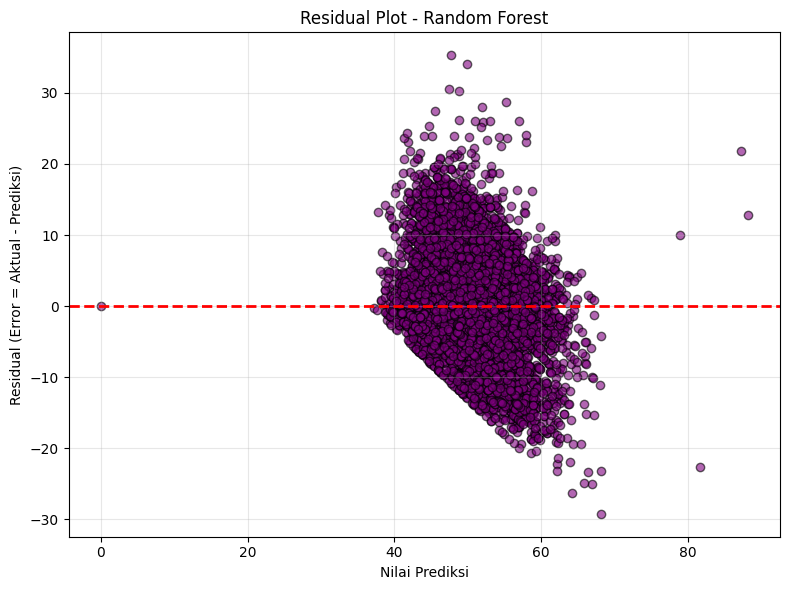

C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


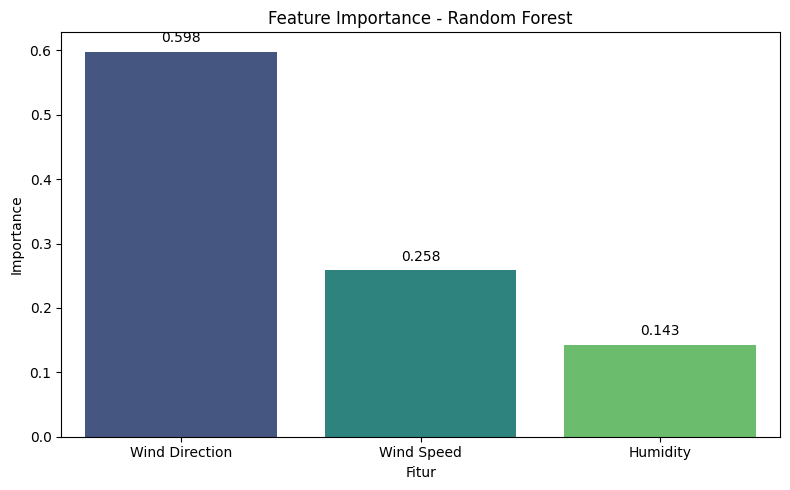

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Opsional, untuk grafik lebih cantik

# Pastikan style grafik rapi
plt.style.use('default')

# --- 1. Scatter Plot: Prediksi vs Nilai Sebenarnya ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='blue', edgecolors='k', label='Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Nilai Sebenarnya (Suhu)')
plt.ylabel('Nilai Prediksi')
plt.title('Random Forest: Nilai Sebenarnya vs Prediksi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Residual Plot ---
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.6, color='purple', edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual (Error = Aktual - Prediksi)')
plt.title('Residual Plot - Random Forest')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. Feature Importance ---
feature_names = ['Wind Direction', 'Wind Speed', 'Humidity']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=[feature_names[i] for i in indices], y=importances[indices], palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.xlabel('Fitur')
plt.xticks(rotation=0)
for i, v in enumerate(importances[indices]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Membuat model ANN
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Kompilasi model
model.compile(optimizer='adam', loss='mean_squared_error')

# Melatih model dan simpan history
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=10,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

# Prediksi suhu pada data test
y_pred_ann = model.predict(X_test_scaled)

# Evaluasi model ANN
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print(f'Jaringan Saraf Tiruan (ANN) - RMSE: {rmse_ann:.4f}, MAE: {mae_ann:.4f}')

Epoch 1/100


C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4256/4256 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 108.2206 - val_loss: 43.1437
Epoch 2/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 43.0298 - val_loss: 43.6365
Epoch 3/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 41.1875 - val_loss: 40.3128
Epoch 4/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 39.9684 - val_loss: 39.4105
Epoch 5/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 39.4380 - val_loss: 39.1974
Epoch 6/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 39.2083 - val_loss: 38.7480
Epoch 7/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 38.9484 - val_loss: 39.3282
Epoch 8/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 38.9189 - val_loss: 39.1896
Epoch 9/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 38.8534 - val_loss: 38.4274
Epoch 10/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 38.8083 - val_loss: 38.2240
Epoch 11/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 38.6376 - val_loss: 37.9148
Epoch 1

Epoch 66/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 36.9492 - val_loss: 36.5838
Epoch 67/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.8770 - val_loss: 36.8753
Epoch 68/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.8532 - val_loss: 37.5166
Epoch 69/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.8075 - val_loss: 38.2222
Epoch 70/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.7794 - val_loss: 36.9076
Epoch 71/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.8521 - val_loss: 37.2701
Epoch 72/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.8260 - val_loss: 36.7507
Epoch 73/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.7741 - val_loss: 36.9157
Epoch 74/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.7582 - val_loss: 36.6193
Epoch 75/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.7425 - val_loss: 37.3057
Epoch 76/100
4256/4256 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 36.7125 - val_l

In [30]:
model.save('model_ann_suhu.keras')  # Format .keras (baru, lebih baik)

In [31]:
from tensorflow.keras.models import load_model

# Muat model
model = load_model('model_ann_suhu.keras')  # atau 'model_ann_suhu.h5'

# Langsung prediksi
y_pred = model.predict(X_test_scaled)

333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


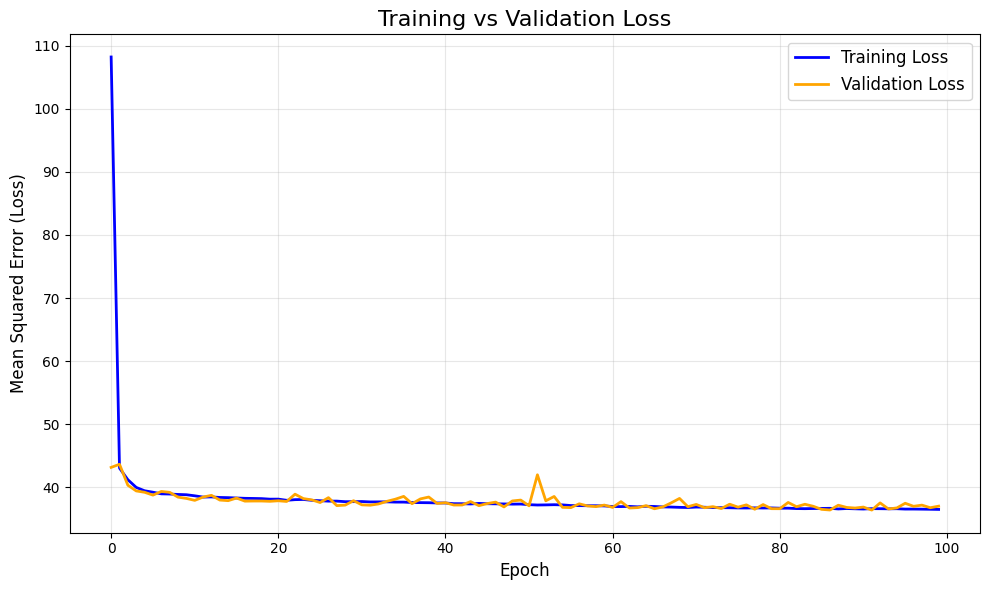

In [32]:
# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

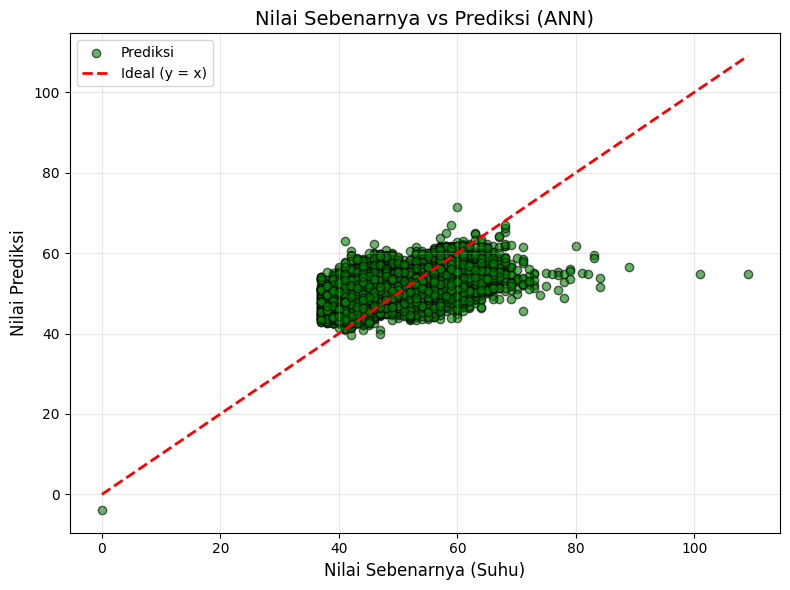

In [33]:
# Plot Prediksi vs Nilai Sebenarnya
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ann, alpha=0.6, color='green', edgecolors='k', label='Prediksi')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Nilai Sebenarnya (Suhu)', fontsize=12)
plt.ylabel('Nilai Prediksi', fontsize=12)
plt.title('Nilai Sebenarnya vs Prediksi (ANN)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Reshape data menjadi 3D [samples, timesteps, features] untuk LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Membuat model LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
model.add(Dense(1))

# Kompilasi model
model.compile(optimizer='adam', loss='mse')

# Melatih model
#model.fit(X_train_lstm, y_train, epochs=100, batch_size=32, validation_data=(X_test_lstm, y_test))
history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    verbose=1
)

# Prediksi
y_pred_lstm = model.predict(X_test_lstm)

# Evaluasi
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)

print(f'LSTM - RMSE: {rmse_lstm}, MAE: {mae_lstm}')


Epoch 1/100


C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1330/1330 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 954.6960 - val_loss: 166.2410
Epoch 2/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 75.4639 - val_loss: 46.4603
Epoch 3/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 43.9196 - val_loss: 43.3868
Epoch 4/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 42.4437 - val_loss: 42.4621
Epoch 5/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.7506 - val_loss: 42.0706
Epoch 6/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.3424 - val_loss: 41.9510
Epoch 7/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 41.0995 - val_loss: 41.3652
Epoch 8/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40.9128 - val_loss: 41.1843
Epoch 9/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40.7637 - val_loss: 41.0069
Epoch 10/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 40.6329 - val_loss: 40.9385
Epoch 11/100
1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40.5430 - val_loss: 40.8511
Epoch 1

In [35]:
model.save('model_LSTM_suhu.keras')  # Format .keras (baru, lebih baik)

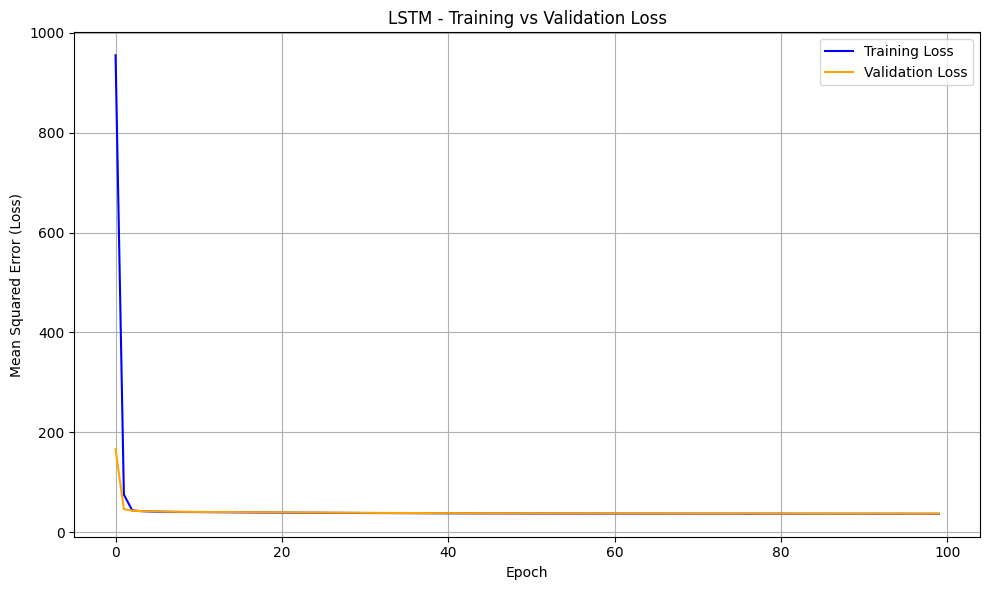

In [36]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('LSTM - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

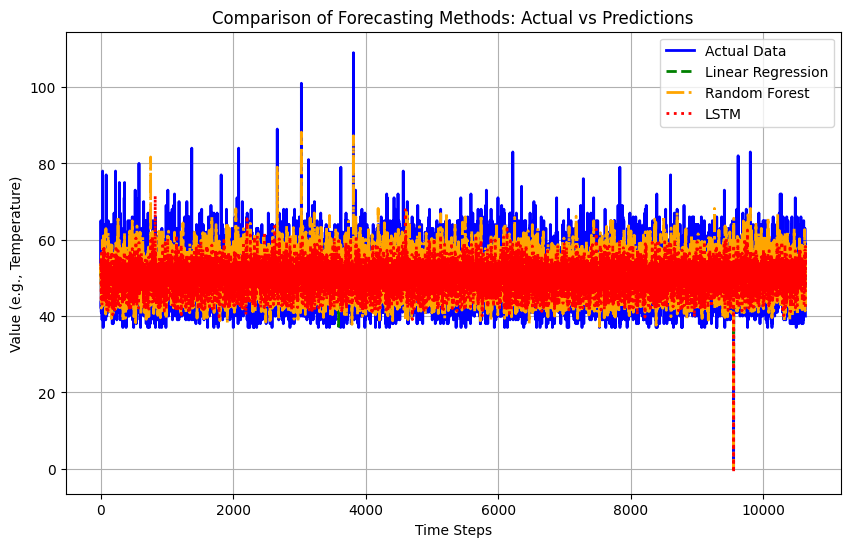

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Contoh data (gantilah dengan data sebenarnya)
time_steps = np.arange(len(y_test))  # Asumsi data urutan waktu
# Misalkan kita memiliki prediksi dari regresi, random forest, dan LSTM

# Membuat plot
plt.figure(figsize=(10,6))

# Plot data aktual
plt.plot(time_steps, y_test, label='Actual Data', color='blue', linestyle='-', linewidth=2)

# Plot hasil prediksi dari Regresi Linier
plt.plot(time_steps, y_pred_lin_reg, label='Linear Regression', color='green', linestyle='--', linewidth=2)

# Plot hasil prediksi dari Random Forest
plt.plot(time_steps, y_pred_rf, label='Random Forest', color='orange', linestyle='-.', linewidth=2)

# Plot hasil prediksi dari LSTM
plt.plot(time_steps, y_pred_lstm, label='LSTM', color='red', linestyle=':', linewidth=2)

# Menambahkan judul dan label sumbu
plt.title('Comparison of Forecasting Methods: Actual vs Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Value (e.g., Temperature)')

# Menambahkan legenda
plt.legend()

# Menambahkan grid
plt.grid(True)

# Menampilkan plot
plt.show()


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# RMSE dan MAE untuk Linear Regression
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))
mae_reg = mean_absolute_error(y_test, y_pred_lin_reg)

# RMSE dan MAE untuk Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# RMSE dan MAE untuk LSTM
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)

# Cetak hasil evaluasi
print(f'Linear Regression - RMSE: {rmse_reg:.2f}, MAE: {mae_reg:.2f}')
print(f'Random Forest - RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}')
print(f'LSTM - RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}')


Linear Regression - RMSE: 6.75, MAE: 5.56
Random Forest - RMSE: 6.47, MAE: 4.81
LSTM - RMSE: 6.12, MAE: 4.81


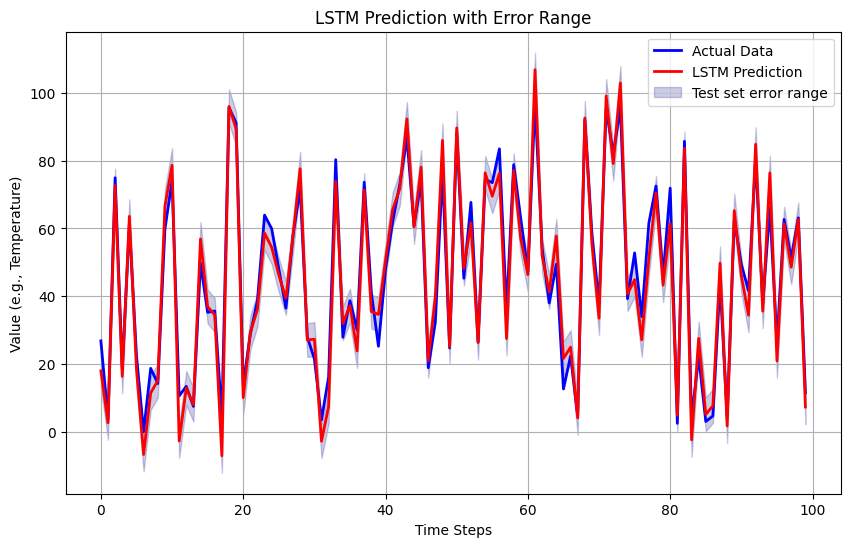

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Contoh data
n = 100  # Panjang data yang sama
time_steps = np.arange(n)  # Time steps harus memiliki panjang yang sama dengan data lainnya

# Data aktual dan prediksi
y_test = np.random.rand(n) * 100  # Data aktual dengan panjang n
y_pred_lstm = y_test + np.random.randn(n) * 5  # Prediksi LSTM dengan panjang n

# Tentukan upper dan lower bound untuk range kesalahan prediksi
error_margin = 5  # Margin error yang ingin ditampilkan
lower_bound = y_pred_lstm - error_margin
upper_bound = y_pred_lstm + error_margin

# Membuat plot
plt.figure(figsize=(10,6))

# Plot data aktual
plt.plot(time_steps, y_test, label='Actual Data', color='blue', linestyle='-', linewidth=2)

# Plot prediksi LSTM
plt.plot(time_steps, y_pred_lstm, label='LSTM Prediction', color='red', linestyle='-', linewidth=2)

# Plot shaded area untuk range kesalahan prediksi
plt.fill_between(time_steps, lower_bound, upper_bound, color='navy', alpha=0.2, label='Test set error range')

# Menambahkan judul dan label sumbu
plt.title('LSTM Prediction with Error Range')
plt.xlabel('Time Steps')
plt.ylabel('Value (e.g., Temperature)')

# Menambahkan legenda
plt.legend()

# Menampilkan grid
plt.grid(True)

# Menampilkan plot
plt.show()
